In [6]:
import numpy as np
from numpy.testing import assert_allclose
from scipy.stats import ks_2samp, spearmanr

from multicam.multicam import MultiCAM, multicam_prediction
from multicam.train import get_tt_indices
from multicam.qt import qt

import matplotlib.pyplot as plt 

In [4]:
rng = np.random.default_rng(42)
x = rng.standard_normal(10_000) * 5 + 4
# small noise compared to x scatter
y = rng.standard_normal(10_000) * 0.5 + 2 * x + 10

In [5]:
# cam 
y_pred_cam = qt(x, y)

In [11]:
# multicam
model = MultiCAM(1, 1)
model.fit(x.reshape(-1, 1), y.reshape(-1, 1))
y_pred_multicam = model.predict(x.reshape(-1, 1))

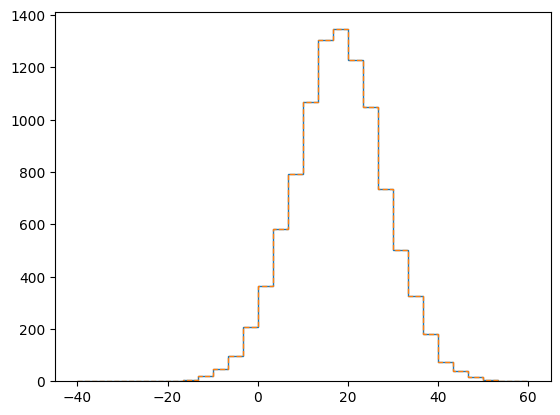

In [19]:
bins = np.linspace(-40, 60, 31)

plt.hist(y_pred_cam, bins=bins, histtype='step')
plt.hist(y_pred_multicam, bins=bins, histtype='step', linestyle='--');

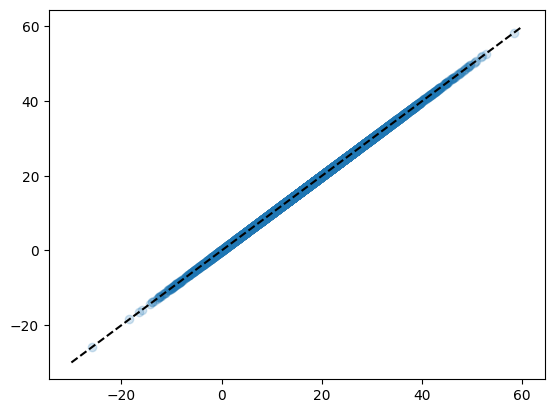

In [18]:
plt.scatter(y_pred_cam, y_pred_multicam, alpha=0.2)
plt.plot([-30, 60], [-30, 60], c='k', ls='--')

# Repeats

In [65]:
n_points = 10_000
rng = np.random.default_rng(42)
random_indices = rng.choice(np.arange(n_points), replace=False, size=(9500,))

x = rng.standard_normal(size=(n_points, 2)) * 2 + 1
x[random_indices, 1] = 1.0
y = rng.standard_normal(n_points) * 0.5 + 2 * x[:, 0] + 3 * x[:, 1] + 10
y = y.reshape(-1, 1)

In [66]:
# multicam
model = MultiCAM(2, 1)
model.fit(x, y)
y_pred = model.predict(x)

(array([0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 2.000e+00, 4.000e+00, 2.700e+01, 8.700e+01, 3.100e+02,
        8.390e+02, 1.504e+03, 2.252e+03, 2.163e+03, 1.490e+03, 8.240e+02,
        3.360e+02, 1.170e+02, 3.000e+01, 1.000e+01, 3.000e+00, 2.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00]),
 array([-20.        , -17.66666667, -15.33333333, -13.        ,
        -10.66666667,  -8.33333333,  -6.        ,  -3.66666667,
         -1.33333333,   1.        ,   3.33333333,   5.66666667,
          8.        ,  10.33333333,  12.66666667,  15.        ,
         17.33333333,  19.66666667,  22.        ,  24.33333333,
         26.66666667,  29.        ,  31.33333333,  33.66666667,
         36.        ,  38.33333333,  40.66666667,  43.        ,
         45.33333333,  47.66666667,  50.        ]),
 [<matplotlib.patches.Polygon at 0x7846347cfb10>])

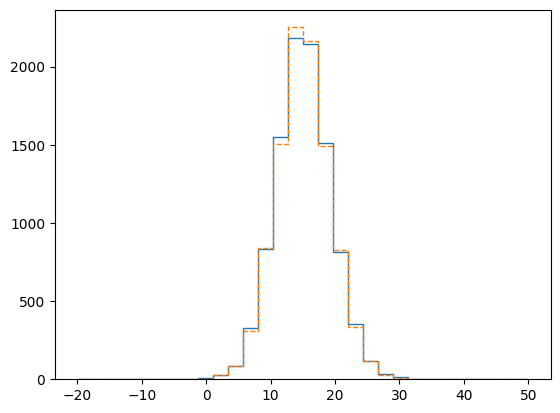

In [67]:
bins= np.linspace(-20, 50, 31)
plt.hist(y, bins=bins, histtype='step')
plt.hist(y_pred, bins=bins, histtype='step', linestyle='--')